# Mutual Fund Performance Analytics

## Objective

Evaluate the performance and risk characteristics of 40 mutual fund schemes using:

- Daily Returns
- CAGR
- Sharpe Ratio
- Sortino Ratio
- Alpha and Beta
- Maximum Drawdown
- Composite Fund Scorecard
- Benchmark Comparison

## 1. Data Preparation

The analysis uses mutual fund NAV history and fund master data.

The NAV history is used to calculate returns and risk metrics, while the fund master provides fund-level information such as scheme name and expense ratio.

In [41]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
import warnings
warnings.filterwarnings("ignore")

In [42]:
fund_master = pd.read_csv("../DATA/PROCESSED/01_fund_master.csv")
nav_his = pd.read_csv("../DATA/PROCESSED/02_nav_history.csv")

In [43]:
scheme = pd.merge(
    fund_master,
    nav_his,
    on = "amfi_code"
)

In [44]:
scheme.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code,date,nav
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01,2022-01-03,54.3856
1,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01,2022-01-04,54.3474
2,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01,2022-01-05,54.6869
3,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01,2022-01-06,55.4550
4,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01,2022-01-07,55.3692


In [45]:
scheme.shape

(46000, 17)

In [46]:
scheme.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code', 'date', 'nav'],
      dtype='object')

In [47]:
scheme.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           46000 non-null  int64  
 1   fund_house          46000 non-null  object 
 2   scheme_name         46000 non-null  object 
 3   category            46000 non-null  object 
 4   sub_category        46000 non-null  object 
 5   plan                46000 non-null  object 
 6   launch_date         46000 non-null  object 
 7   benchmark           46000 non-null  object 
 8   expense_ratio_pct   46000 non-null  float64
 9   exit_load_pct       46000 non-null  float64
 10  min_sip_amount      46000 non-null  int64  
 11  min_lumpsum_amount  46000 non-null  int64  
 12  fund_manager        46000 non-null  object 
 13  risk_category       46000 non-null  object 
 14  sebi_category_code  46000 non-null  object 
 15  date                46000 non-null  object 
 16  nav 

In [48]:
scheme["launch_date"] = pd.to_datetime(scheme["launch_date"])
scheme["date"] = pd.to_datetime(scheme["date"])

In [49]:
scheme.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   amfi_code           46000 non-null  int64         
 1   fund_house          46000 non-null  object        
 2   scheme_name         46000 non-null  object        
 3   category            46000 non-null  object        
 4   sub_category        46000 non-null  object        
 5   plan                46000 non-null  object        
 6   launch_date         46000 non-null  datetime64[ns]
 7   benchmark           46000 non-null  object        
 8   expense_ratio_pct   46000 non-null  float64       
 9   exit_load_pct       46000 non-null  float64       
 10  min_sip_amount      46000 non-null  int64         
 11  min_lumpsum_amount  46000 non-null  int64         
 12  fund_manager        46000 non-null  object        
 13  risk_category       46000 non-null  object    

In [50]:
scheme.describe()

,amfi_code,launch_date,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,date,nav
count,46000.000000,46000,46000.000000,46000.000000,46000.0,46000.000000,46000,46000.000000
mean,120247.000000,2007-02-21 10:12:00,1.237000,0.812500,500.0,1277.500000,2024-03-16 12:00:00.000000256,269.570265
min,100016.000000,1996-09-11 00:00:00,0.550000,0.000000,500.0,100.000000,2022-01-03 00:00:00,26.136600
25%,118632.750000,2003-12-04 06:00:00,0.787500,1.000000,500.0,1000.000000,2023-02-08 00:00:00,69.170425
50%,119551.500000,2007-04-30 00:00:00,1.425000,1.000000,500.0,1000.000000,2024-03-16 12:00:00,122.732150
75%,120842.250000,2010-10-24 18:00:00,1.540000,1.000000,500.0,1000.000000,2025-04-23 00:00:00,260.338675
max,149324.000000,2015-12-28 00:00:00,1.640000,1.000000,500.0,5000.000000,2026-05-29 00:00:00,4268.549700
std,14352.317221,NaN,0.381725,0.382226,0.0,1069.237394,NaN,577.187060


In [51]:
scheme = scheme.sort_values(["amfi_code", "date"])

In [52]:
scheme["daily_return"] = (scheme.groupby("amfi_code")["nav"].pct_change())

In [53]:
scheme[["scheme_name", "date", "nav", "daily_return"]].head(10)

,scheme_name,date,nav,daily_return
5750,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-03,520.4608,NaN
5751,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-04,515.0971,-0.010306
5752,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-05,521.7239,0.012865
5753,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-06,515.7880,-0.011377
5754,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-07,515.1639,-0.001210
5755,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-10,510.7136,-0.008639
5756,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-11,513.5542,0.005562
5757,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-12,512.3195,-0.002404
5758,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-13,510.2445,-0.004050
5759,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-14,514.3636,0.008073


In [54]:
scheme["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

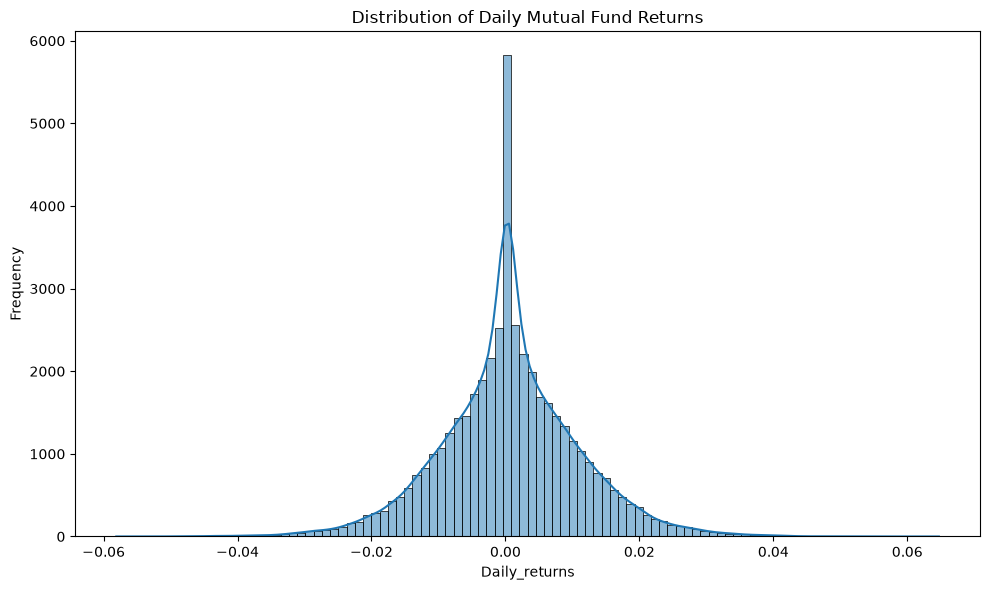

In [55]:
# Histogram 
plt.figure(figsize=(10,6))

sns.histplot(
    scheme["daily_return"].dropna(),
    bins = 100,
    kde = True
)

plt.title("Distribution of Daily Mutual Fund Returns")
plt.xlabel("Daily_returns")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### CAGR (Compound Annual Growth Rate)


In [56]:
scheme["date"].min(), scheme["date"].max() 

(Timestamp('2022-01-03 00:00:00'), Timestamp('2026-05-29 00:00:00'))

In [57]:
test_fund = scheme["scheme_name"].iloc[0]

In [58]:
fund_data = scheme[scheme["scheme_name"] == test_fund].copy()
fund_data[["date", "nav"]].head(10)

,date,nav
5750,2022-01-03,520.4608
5751,2022-01-04,515.0971
5752,2022-01-05,521.7239
5753,2022-01-06,515.7880
5754,2022-01-07,515.1639
5755,2022-01-10,510.7136
5756,2022-01-11,513.5542
5757,2022-01-12,512.3195
5758,2022-01-13,510.2445
5759,2022-01-14,514.3636


In [59]:
fund_data[["date", "nav"]].tail(10)

,date,nav
6890,2026-05-18,590.5865
6891,2026-05-19,609.5709
6892,2026-05-20,603.2283
6893,2026-05-21,605.9387
6894,2026-05-22,602.4801
6895,2026-05-25,599.9335
6896,2026-05-26,596.4426
6897,2026-05-27,590.8555
6898,2026-05-28,590.9452
6899,2026-05-29,583.6113


In [60]:
test_fund = scheme["scheme_name"].iloc[0]

fund_data = (
    scheme[scheme["scheme_name"] == test_fund].sort_values("date")
)

In [61]:
end_date = fund_data["date"].max()

print("Fund: ", test_fund)
print("End Date: ", end_date)

Fund:  HDFC Top 100 Fund - Regular Plan - Growth
End Date:  2026-05-29 00:00:00


In [62]:
one_year_date = end_date - pd.DateOffset(years = 1)

print("1-Year Target: ", one_year_date)

1-Year Target:  2025-05-29 00:00:00


In [63]:
three_year_date = end_date - pd.DateOffset(years = 3)

print("3-Year Target: ",three_year_date)

3-Year Target:  2023-05-29 00:00:00


In [64]:
start_data = fund_data[fund_data["date"] <= one_year_date].iloc[-1]

print(start_data[["date","nav"]])

date    2025-05-29 00:00:00
nav                596.8877
Name: 6638, dtype: object


In [65]:
end_data = fund_data.iloc[-1]

print(end_data[["date","nav"]])

date    2026-05-29 00:00:00
nav                583.6113
Name: 6899, dtype: object


In [66]:
cagr_1y = (end_data["nav"]/start_data["nav"]) ** (1/1) - 1
print(cagr_1y)

-0.02224270997710287


In [67]:
# 3 Year
cagr_3y = (end_data["nav"] / start_data["nav"]) ** (1/3) - 1
print(cagr_3y)

-0.007469897082966193


In [68]:
cagr_results = []

In [69]:
for fund_name, fund_data in scheme.groupby("scheme_name"):

    fund_data = fund_data.sort_values("date")

    end_date = fund_data["date"].max()
    end_nav = fund_data.iloc[-1]["nav"]

    # 1-year
    target_1y = end_date - pd.DateOffset(years=1)

    data_1y = fund_data[
        fund_data["date"] <= target_1y
    ]

    cagr_1y = np.nan

    if len(data_1y) > 0:
        start_nav_1y = data_1y.iloc[-1]["nav"]
        cagr_1y = (end_nav / start_nav_1y) ** (1/1) - 1

    # 3-year
    target_3y = end_date - pd.DateOffset(years=3)

    data_3y = fund_data[
        fund_data["date"] <= target_3y
    ]

    cagr_3y = np.nan

    if len(data_3y) > 0:
        start_nav_3y = data_3y.iloc[-1]["nav"]
        cagr_3y = (end_nav / start_nav_3y) ** (1/3) - 1

    cagr_results.append({
        "scheme_name": fund_name,
        "CAGR_1Y": cagr_1y,
        "CAGR_3Y": cagr_3y
    })

In [70]:
cagr_table = pd.DataFrame(cagr_results)


In [71]:
cagr_table.head()

,scheme_name,CAGR_1Y,CAGR_3Y
0,ABSL Frontline Equity Fund - Regular - Growth,0.479241,0.289677
1,ABSL Liquid Fund - Regular - Growth,0.072366,0.063158
2,ABSL Small Cap Fund - Regular - Growth,-0.239860,-0.041524
3,Axis Bluechip Fund - Direct - Growth,0.197667,0.208168
4,Axis Bluechip Fund - Regular - Growth,0.016091,0.005259


In [72]:
cagr_table.shape

(40, 3)

In [73]:
cagr_table["CAGR_1Y"] = cagr_table["CAGR_1Y"] * 100
cagr_table["CAGR_3Y"] = cagr_table["CAGR_3Y"] * 100

In [74]:
cagr_table.round(2)

,scheme_name,CAGR_1Y,CAGR_3Y
0,ABSL Frontline Equity Fund - Regular - Growth,47.92,28.97
1,ABSL Liquid Fund - Regular - Growth,7.24,6.32
2,ABSL Small Cap Fund - Regular - Growth,-23.99,-4.15
3,Axis Bluechip Fund - Direct - Growth,19.77,20.82
4,Axis Bluechip Fund - Regular - Growth,1.61,0.53
5,Axis Midcap Fund - Regular - Growth,22.26,35.11
6,Axis Small Cap Fund - Regular - Growth,-42.80,-11.71
7,DSP Midcap Fund - Regular - Growth,21.48,26.87
8,DSP Small Cap Fund - Regular - Growth,65.14,27.00
9,DSP Top 100 Equity Fund - Regular - Growth,18.11,18.04


### CAGR Data Limitation

The available NAV history runs from January 2022 to May 2026, providing sufficient history for 1-year and 3-year CAGR calculations but not a complete 5-year period. Therefore, 5-year CAGR is not calculated to avoid overstating the available historical performance.

### SHARPE RATIO 

In [75]:
test_fund = scheme["scheme_name"].iloc[0]

fund_returns = scheme[scheme["scheme_name"] == test_fund]["daily_return"].dropna()

In [76]:
mean_daily_return = fund_returns.mean()

print(mean_daily_return)

0.00014159930699210853


In [77]:
daily_std = fund_returns.std()

print(daily_std)

0.009164463506291045


In [78]:
annual_return = mean_daily_return * 252
annual_std = daily_std * np.sqrt(252)

print("Annual Return:", annual_return)
print("Annual Volatility:", annual_std)

Annual Return: 0.03568302536201135
Annual Volatility: 0.14548134802183876


In [79]:
risk_free_rate = 0.065
sharpe = ((fund_returns.mean() - risk_free_rate / 252) / fund_returns.std()) * np.sqrt(252)

print("Sharpe Ratio:",sharpe)

Sharpe Ratio: -0.2015170675596694


In [80]:
sharpe_results = []

risk_free_rate = 0.065

for fund_name, fund_data in scheme.groupby("scheme_name"):

    returns = fund_data["daily_return"].dropna()

    sharpe = (
        (returns.mean() - risk_free_rate / 252)
        / returns.std()
    ) * np.sqrt(252)

    sharpe_results.append({
        "scheme_name": fund_name,
        "sharpe_ratio": sharpe
    })

sharpe_table = pd.DataFrame(sharpe_results)

In [81]:
sharpe_table.round(3)

,scheme_name,sharpe_ratio
0,ABSL Frontline Equity Fund - Regular - Growth,1.027
1,ABSL Liquid Fund - Regular - Growth,-0.816
2,ABSL Small Cap Fund - Regular - Growth,0.163
3,Axis Bluechip Fund - Direct - Growth,0.130
4,Axis Bluechip Fund - Regular - Growth,0.031
5,Axis Midcap Fund - Regular - Growth,0.998
6,Axis Small Cap Fund - Regular - Growth,-0.076
7,DSP Midcap Fund - Regular - Growth,1.132
8,DSP Small Cap Fund - Regular - Growth,0.950
9,DSP Top 100 Equity Fund - Regular - Growth,0.464


In [82]:
sharpe_table = sharpe_table.sort_values("sharpe_ratio", ascending = False).reset_index(drop=True)

In [83]:
sharpe_table["sharpe_rank"] = (sharpe_table.index + 1)

In [84]:
sharpe_table.head()

,scheme_name,sharpe_ratio,sharpe_rank
0,Mirae Asset Large Cap Fund - Regular - Growth,1.448291,1
1,Kotak Flexicap Fund - Regular - Growth,1.306744,2
2,Mirae Asset Tax Saver Fund - Regular - Growth,1.234930,3
3,SBI Bluechip Fund - Regular Plan - Growth,1.208267,4
4,ICICI Pru Midcap Fund - Regular - Growth,1.180101,5


#### SORTINO RATIO

In [85]:
test_fund = scheme["scheme_name"].iloc[0]

fund_returns = scheme[scheme["scheme_name"] == test_fund]["daily_return"].dropna()

In [86]:
downside_returns = fund_returns[fund_returns < 0]
downside_returns.describe()

count    579.000000
mean      -0.007131
std        0.005261
min       -0.024744
25%       -0.010457
50%       -0.006223
75%       -0.002704
max       -0.000002
Name: daily_return, dtype: float64

In [87]:
downside_std = downside_returns.std()

In [88]:
sortino = ((fund_returns.mean() - risk_free_rate / 252) / downside_std) * np.sqrt(252)

print("Sortino Ratio:", sortino)

Sortino Ratio: -0.35104746015230903


In [89]:
sortino_results = []

risk_free_rate = 0.065

for fund_name, fund_data in scheme.groupby("scheme_name"):

    returns = fund_data["daily_return"].dropna()

    downside_returns = returns[returns < 0]

    downside_std = downside_returns.std()

    sortino = (
        (returns.mean() - risk_free_rate / 252)
        / downside_std
    ) * np.sqrt(252)

    sortino_results.append({
        "scheme_name": fund_name,
        "sortino_ratio": sortino
    })

sortino_table = pd.DataFrame(sortino_results)

In [90]:
sortino_table = sortino_table.sort_values(
    "sortino_ratio",
    ascending=False
).reset_index(drop=True)

sortino_table["sortino_rank"] = sortino_table.index + 1

In [91]:
sortino_table.head(10)

,scheme_name,sortino_ratio,sortino_rank
0,Mirae Asset Large Cap Fund - Regular - Growth,2.385644,1
1,Kotak Flexicap Fund - Regular - Growth,2.364320,2
2,Mirae Asset Tax Saver Fund - Regular - Growth,2.146914,3
3,SBI Bluechip Fund - Regular Plan - Growth,2.140267,4
4,ICICI Pru Midcap Fund - Regular - Growth,2.029353,5
5,DSP Midcap Fund - Regular - Growth,1.875101,6
6,Nippon India Large Cap Fund - Regular - Growth,1.850133,7
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.829134,8
8,ICICI Pru Bluechip Fund - Direct - Growth,1.805294,9
9,ABSL Frontline Equity Fund - Regular - Growth,1.799563,10


### Alpha & Beta

In [92]:
benchmark = pd.read_csv("../DATA/PROCESSED/10_benchmark_indices.csv")
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [93]:
benchmark.shape

(8050, 3)

In [94]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='object')

In [95]:
benchmark.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         8050 non-null   object 
 1   index_name   8050 non-null   object 
 2   close_value  8050 non-null   float64
dtypes: float64(1), object(2)
memory usage: 188.8+ KB


In [96]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [97]:
benchmark["index_name"].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [98]:
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

In [99]:
nifty100 = nifty100.sort_values("date")
nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [100]:
nifty100["benchmark_return"]=(nifty100["close_value"].pct_change())

In [101]:
nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [102]:
test_fund = scheme["scheme_name"].iloc[0]

fund_test = scheme[scheme["scheme_name"] == test_fund][["date", "daily_return"]].copy()

In [103]:
fund_test = fund_test.rename(columns={"daily_return": "fund_return"})

In [104]:
reg_data = pd.merge(
    fund_test,
    nifty100[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

In [105]:
reg_data.head()

,date,fund_return,benchmark_return
0,2022-01-03,NaN,NaN
1,2022-01-04,-0.010306,-0.013540
2,2022-01-05,0.012865,0.004003
3,2022-01-06,-0.011377,-0.002935
4,2022-01-07,-0.001210,0.006150


In [106]:
reg_data = reg_data.dropna()

In [107]:
reg_data.shape

(1149, 3)

In [108]:
result = linregress(reg_data["benchmark_return"], reg_data["fund_return"])
print(result)

LinregressResult(slope=np.float64(-0.05826843143880895), intercept=np.float64(0.0001487135223588604), rvalue=np.float64(-0.051623954692887754), pvalue=np.float64(0.08026442483699585), stderr=np.float64(0.033282877789576594), intercept_stderr=np.float64(0.00027015059491085184))


In [109]:
beta =result.slope
daily_alpha = result.intercept
alpha = daily_alpha * 252

In [110]:
print("Fund:", test_fund)
print("Beta:", beta)
print("Annual Alpha:", alpha)

Fund: HDFC Top 100 Fund - Regular Plan - Growth
Beta: -0.05826843143880895
Annual Alpha: 0.03747580763443282


In [111]:
print("Fund:", test_fund)
print("Beta:", round(beta, 4))
print("Annual Alpha:", round(alpha * 100, 2), "%")

Fund: HDFC Top 100 Fund - Regular Plan - Growth
Beta: -0.0583
Annual Alpha: 3.75 %


In [112]:
reg_data[["fund_return", "benchmark_return"]].describe()

,fund_return,benchmark_return
count,1149.000000,1149.000000
mean,0.000142,0.000122
std,0.009164,0.008119
min,-0.024744,-0.026873
25%,-0.006282,-0.005385
50%,-0.000070,-0.000112
75%,0.006523,0.005456
max,0.032145,0.026795


In [113]:
reg_data[["fund_return", "benchmark_return"]].corr()

,fund_return,benchmark_return
fund_return,1.000000,-0.051624
benchmark_return,-0.051624,1.000000


In [114]:
print("Observations:", len(reg_data))
print("Correlation:", reg_data["fund_return"].corr(
    reg_data["benchmark_return"]
))
print("R-squared:", result.rvalue ** 2)

Observations: 1149
Correlation: -0.05162395469288775
R-squared: 0.0026650326981333275


In [115]:
nifty100[["date", "close_value", "benchmark_return"]].head(10)

,date,close_value,benchmark_return
1150,2022-01-03,17778.24,NaN
1151,2022-01-04,17537.52,-0.013540
1152,2022-01-05,17607.73,0.004003
1153,2022-01-06,17556.05,-0.002935
1154,2022-01-07,17664.02,0.006150
1155,2022-01-10,17516.51,-0.008351
1156,2022-01-11,17603.08,0.004942
1157,2022-01-12,17763.76,0.009128
1158,2022-01-13,17830.30,0.003746
1159,2022-01-14,17578.93,-0.014098


In [116]:
nifty100["benchmark_return"].describe()

count    1149.000000
mean        0.000122
std         0.008119
min        -0.026873
25%        -0.005385
50%        -0.000112
75%         0.005456
max         0.026795
Name: benchmark_return, dtype: float64

In [117]:
fund_test[["date", "fund_return"]].head(10)

,date,fund_return
5750,2022-01-03,NaN
5751,2022-01-04,-0.010306
5752,2022-01-05,0.012865
5753,2022-01-06,-0.011377
5754,2022-01-07,-0.001210
5755,2022-01-10,-0.008639
5756,2022-01-11,0.005562
5757,2022-01-12,-0.002404
5758,2022-01-13,-0.004050
5759,2022-01-14,0.008073


In [118]:
fund_test["fund_return"].describe()

count    1149.000000
mean        0.000142
std         0.009164
min        -0.024744
25%        -0.006282
50%        -0.000070
75%         0.006523
max         0.032145
Name: fund_return, dtype: float64

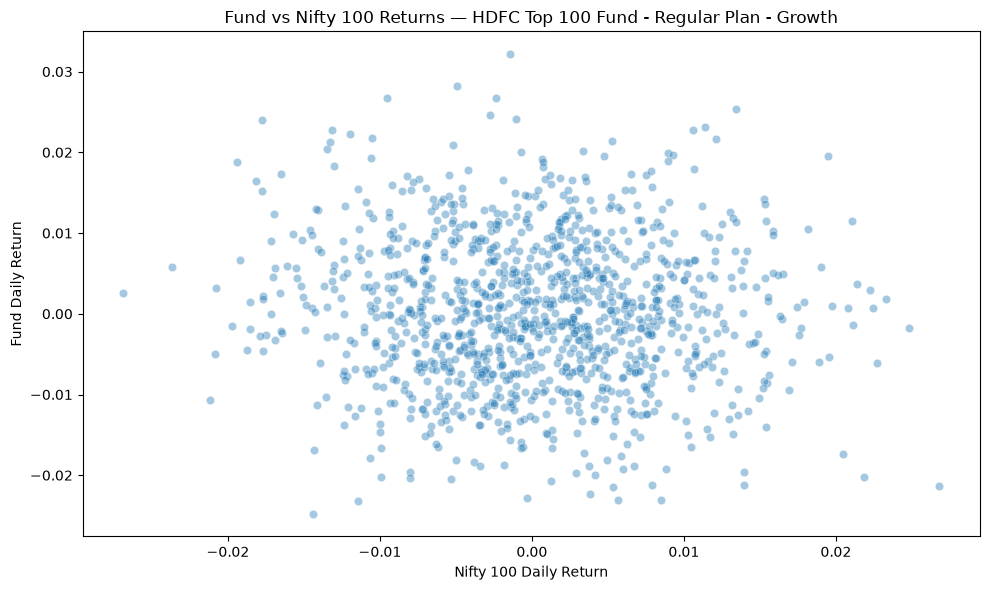

In [119]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=reg_data,
    x="benchmark_return",
    y="fund_return",
    alpha=0.4
)

plt.title(f"Fund vs Nifty 100 Returns — {test_fund}")
plt.xlabel("Nifty 100 Daily Return")
plt.ylabel("Fund Daily Return")

plt.tight_layout()
plt.show()

In [120]:
reg_data[["fund_return", "benchmark_return"]].corr()

,fund_return,benchmark_return
fund_return,1.000000,-0.051624
benchmark_return,-0.051624,1.000000


In [121]:
print("Observations:", len(reg_data))
print("R-squared:", result.rvalue ** 2)

Observations: 1149
R-squared: 0.0026650326981333275


In [122]:
reg_data["fund_return"].cov(
    reg_data["benchmark_return"]
)

np.float64(-3.841344938818552e-06)

In [123]:
reg_data["benchmark_return"].var()

np.float64(6.5924975908311e-05)

In [124]:
beta_manual = (
    reg_data["fund_return"].cov(
        reg_data["benchmark_return"]
    )
    /
    reg_data["benchmark_return"].var()
)

print(beta_manual)

-0.05826843143880895


### Alpha-Beta Validation

Alpha and Beta were estimated using OLS regression of each fund's
daily returns against Nifty 100 daily returns.

For the HDFC Top 100 Fund example, the estimated Beta was -0.0583
with an R² of 0.0027. This indicates that the Nifty 100 benchmark
has very limited explanatory power for this fund's daily returns
in the available dataset. The result was retained as calculated
rather than manually adjusted.

In [125]:
alpha_beta_results = []

for fund_name, fund_data in scheme.groupby("scheme_name"):

    fund_returns = fund_data[
        ["date", "daily_return"]
    ].dropna()

    fund_returns = fund_returns.rename(
        columns={"daily_return": "fund_return"}
    )

    # Match fund returns with Nifty 100 returns by date
    reg_data = pd.merge(
        fund_returns,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    # Regression
    result = linregress(
        reg_data["benchmark_return"],
        reg_data["fund_return"]
    )

    beta = result.slope
    alpha = result.intercept * 252

    alpha_beta_results.append({
        "scheme_name": fund_name,
        "alpha": alpha,
        "beta": beta
    })

In [126]:
alpha_beta = pd.DataFrame(alpha_beta_results)

In [127]:
alpha_beta.shape

(40, 3)

In [128]:
alpha_beta.round(4)

,scheme_name,alpha,beta
0,ABSL Frontline Equity Fund - Regular - Growth,0.2140,0.0211
1,ABSL Liquid Fund - Regular - Growth,0.0609,0.0003
2,ABSL Small Cap Fund - Regular - Growth,0.1090,-0.0653
3,Axis Bluechip Fund - Direct - Growth,0.0823,0.0259
4,Axis Bluechip Fund - Regular - Growth,0.0690,0.0097
5,Axis Midcap Fund - Regular - Growth,0.2608,-0.0663
6,Axis Small Cap Fund - Regular - Growth,0.0480,-0.0670
7,DSP Midcap Fund - Regular - Growth,0.2660,-0.0025
8,DSP Small Cap Fund - Regular - Growth,0.3006,0.0115
9,DSP Top 100 Equity Fund - Regular - Growth,0.1317,-0.0041


In [129]:
# Here we make alpha easier to read
alpha_beta["alpha_pct"] = alpha_beta["alpha"] * 100

In [130]:
alpha_beta[
    ["scheme_name", "alpha_pct", "beta"]
].sort_values(
    "alpha_pct",
    ascending=False
).head(10)

,scheme_name,alpha_pct,beta
36,SBI Small Cap Fund - Regular Plan - Growth,30.336965,-0.023196
8,DSP Small Cap Fund - Regular - Growth,30.057878,0.011455
18,ICICI Pru Midcap Fund - Regular - Growth,29.263583,0.000549
26,Mirae Asset Tax Saver Fund - Regular - Growth,28.270368,0.018134
22,Kotak Flexicap Fund - Regular - Growth,27.330465,-0.022830
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,27.195355,0.005104
25,Mirae Asset Large Cap Fund - Regular - Growth,26.983751,0.023684
7,DSP Midcap Fund - Regular - Growth,26.598578,-0.002523
5,Axis Midcap Fund - Regular - Growth,26.076669,-0.066265
33,SBI Bluechip Fund - Regular Plan - Growth,23.201007,-0.031751


In [131]:
import os

os.makedirs("../REPORTS", exist_ok=True)

In [236]:
alpha_beta.to_csv(
    "../DATA/PROCESSED/alpha_beta.csv",
    index=False
)

In [237]:
pd.read_csv(
    "../DATA/PROCESSED/alpha_beta.csv"
).head()

,scheme_name,alpha,beta,alpha_pct
0,ABSL Frontline Equity Fund - Regular - Growth,0.213998,0.021086,21.399785
1,ABSL Liquid Fund - Regular - Growth,0.060861,0.000267,6.086146
2,ABSL Small Cap Fund - Regular - Growth,0.108971,-0.065289,10.897092
3,Axis Bluechip Fund - Direct - Growth,0.082328,0.025883,8.232801
4,Axis Bluechip Fund - Regular - Growth,0.068995,0.009731,6.899530


In [134]:
test_fund = scheme["scheme_name"].iloc[0]

fund_data = scheme[
    scheme["scheme_name"] == test_fund
].sort_values("date").copy()

In [135]:
fund_data["running_max"] = (
    fund_data["nav"].cummax()
)

In [136]:
# Calculate drawdown
fund_data["drawdown"] = (
    fund_data["nav"] /
    fund_data["running_max"]
) - 1

In [137]:
fund_data[
    ["date", "nav", "running_max", "drawdown"]
].tail(10)

,date,nav,running_max,drawdown
6890,2026-05-18,590.5865,669.7236,-0.118164
6891,2026-05-19,609.5709,669.7236,-0.089817
6892,2026-05-20,603.2283,669.7236,-0.099288
6893,2026-05-21,605.9387,669.7236,-0.095241
6894,2026-05-22,602.4801,669.7236,-0.100405
6895,2026-05-25,599.9335,669.7236,-0.104207
6896,2026-05-26,596.4426,669.7236,-0.109420
6897,2026-05-27,590.8555,669.7236,-0.117762
6898,2026-05-28,590.9452,669.7236,-0.117628
6899,2026-05-29,583.6113,669.7236,-0.128579


In [138]:
# Wrost drawdown
max_drawdown = fund_data["drawdown"].min()

print("Fund:", test_fund)
print("Maximum Drawdown:", max_drawdown)

Fund: HDFC Top 100 Fund - Regular Plan - Growth
Maximum Drawdown: -0.24734440880673303


In [139]:
# Drawdown date
worst_row = fund_data.loc[
    fund_data["drawdown"].idxmin()
]

print(worst_row[
    ["date", "nav", "drawdown"]
])

date        2022-09-15 00:00:00
nav                    411.1759
drawdown              -0.247344
Name: 5933, dtype: object


In [140]:
peak_nav = worst_row["running_max"]

peak_row = fund_data[
    fund_data["nav"] == peak_nav
].iloc[0]

print("Peak Date:", peak_row["date"])
print("Trough Date:", worst_row["date"])

Peak Date: 2022-03-30 00:00:00
Trough Date: 2022-09-15 00:00:00


In [141]:
print("Fund:", test_fund)
print("Maximum Drawdown:", max_drawdown)
print("Peak Date:", peak_row["date"])
print("Trough Date:", worst_row["date"])

Fund: HDFC Top 100 Fund - Regular Plan - Growth
Maximum Drawdown: -0.24734440880673303
Peak Date: 2022-03-30 00:00:00
Trough Date: 2022-09-15 00:00:00


In [142]:
fund_data["running_max"] = fund_data["nav"].cummax()

fund_data["drawdown"] = (
    fund_data["nav"] / fund_data["running_max"]
) - 1

In [143]:
drawdown_results = []

for fund_name, fund_data in scheme.groupby("scheme_name"):

    fund_data = fund_data.sort_values("date").copy()

    # Highest NAV reached up to each date
    fund_data["running_max"] = fund_data["nav"].cummax()

    # Decline from the previous peak
    fund_data["drawdown"] = (
        fund_data["nav"] / fund_data["running_max"]
    ) - 1

    # Worst drawdown
    worst_idx = fund_data["drawdown"].idxmin()
    worst_row = fund_data.loc[worst_idx]

    # Peak that occurred before the trough
    peak_nav = worst_row["running_max"]

    peak_data = fund_data[
        fund_data["nav"] == peak_nav
    ]

    peak_row = peak_data.iloc[0]

    drawdown_results.append({
        "scheme_name": fund_name,
        "max_drawdown": worst_row["drawdown"],
        "peak_date": peak_row["date"],
        "trough_date": worst_row["date"]
    })

In [144]:
drawdown_table = pd.DataFrame(drawdown_results)

In [145]:
drawdown_table.shape

(40, 4)

In [146]:
drawdown_table.sort_values(
    "max_drawdown"
).head(10)

,scheme_name,max_drawdown,peak_date,trough_date
35,SBI Small Cap Fund - Direct Plan - Growth,-0.525742,2023-01-17,2025-10-28
6,Axis Small Cap Fund - Regular - Growth,-0.516778,2025-05-22,2026-05-11
2,ABSL Small Cap Fund - Regular - Growth,-0.354469,2024-11-21,2026-05-11
8,DSP Small Cap Fund - Regular - Growth,-0.311719,2024-05-03,2025-01-03
36,SBI Small Cap Fund - Regular Plan - Growth,-0.287060,2024-08-28,2025-05-14
38,UTI Mid Cap Fund - Regular - Growth,-0.280011,2025-01-07,2026-04-27
14,HDFC Top 100 Fund - Regular Plan - Growth,-0.247344,2022-03-30,2022-09-15
21,Kotak Emerging Equity Fund - Regular - Growth,-0.240035,2023-11-09,2024-10-17
31,Nippon India Small Cap Fund - Regular - Growth,-0.233449,2025-04-09,2026-02-20
3,Axis Bluechip Fund - Direct - Growth,-0.217514,2022-02-24,2023-05-22


In [147]:
fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')

In [148]:
fund_master[
    ["scheme_name", "expense_ratio_pct"]
].head()

,scheme_name,expense_ratio_pct
0,SBI Bluechip Fund - Regular Plan - Growth,1.54
1,SBI Bluechip Fund - Direct Plan - Growth,0.66
2,SBI Small Cap Fund - Regular Plan - Growth,1.43
3,SBI Small Cap Fund - Direct Plan - Growth,0.72
4,SBI Magnum Gilt Fund - Regular Plan - Growth,0.77


In [149]:
cagr_table.head()

,scheme_name,CAGR_1Y,CAGR_3Y
0,ABSL Frontline Equity Fund - Regular - Growth,47.924120,28.967695
1,ABSL Liquid Fund - Regular - Growth,7.236645,6.315784
2,ABSL Small Cap Fund - Regular - Growth,-23.986032,-4.152381
3,Axis Bluechip Fund - Direct - Growth,19.766741,20.816771
4,Axis Bluechip Fund - Regular - Growth,1.609119,0.525887


In [150]:
scorecard = cagr_table[
    ["scheme_name", "CAGR_3Y"]
].merge(
    sharpe_table[
        ["scheme_name", "sharpe_ratio"]
    ],
    on="scheme_name",
    how="inner"
)

In [151]:
scorecard.shape

(40, 3)

In [152]:
scorecard = scorecard.merge(
    alpha_beta[
        ["scheme_name", "alpha"]
    ],
    on="scheme_name",
    how="inner"
)

In [153]:
scorecard.head()

,scheme_name,CAGR_3Y,sharpe_ratio,alpha
0,ABSL Frontline Equity Fund - Regular - Growth,28.967695,1.027213,0.213998
1,ABSL Liquid Fund - Regular - Growth,6.315784,-0.815567,0.060861
2,ABSL Small Cap Fund - Regular - Growth,-4.152381,0.162661,0.108971
3,Axis Bluechip Fund - Direct - Growth,20.816771,0.129614,0.082328
4,Axis Bluechip Fund - Regular - Growth,0.525887,0.030785,0.068995


In [154]:
expense_data = fund_master[
    ["scheme_name", "expense_ratio_pct"]
].drop_duplicates("scheme_name")

In [155]:
scorecard = scorecard.merge(
    expense_data,
    on="scheme_name",
    how="left"
)

In [156]:
scorecard.head()

,scheme_name,CAGR_3Y,sharpe_ratio,alpha,expense_ratio_pct
0,ABSL Frontline Equity Fund - Regular - Growth,28.967695,1.027213,0.213998,1.60
1,ABSL Liquid Fund - Regular - Growth,6.315784,-0.815567,0.060861,0.79
2,ABSL Small Cap Fund - Regular - Growth,-4.152381,0.162661,0.108971,1.53
3,Axis Bluechip Fund - Direct - Growth,20.816771,0.129614,0.082328,0.75
4,Axis Bluechip Fund - Regular - Growth,0.525887,0.030785,0.068995,1.64


In [157]:
scorecard = scorecard.merge(
    drawdown_table[
        ["scheme_name", "max_drawdown"]
    ],
    on="scheme_name",
    how="inner"
)

In [158]:
scorecard.shape

(40, 6)

In [159]:
scorecard.head()

,scheme_name,CAGR_3Y,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown
0,ABSL Frontline Equity Fund - Regular - Growth,28.967695,1.027213,0.213998,1.60,-0.112916
1,ABSL Liquid Fund - Regular - Growth,6.315784,-0.815567,0.060861,0.79,-0.001622
2,ABSL Small Cap Fund - Regular - Growth,-4.152381,0.162661,0.108971,1.53,-0.354469
3,Axis Bluechip Fund - Direct - Growth,20.816771,0.129614,0.082328,0.75,-0.217514
4,Axis Bluechip Fund - Regular - Growth,0.525887,0.030785,0.068995,1.64,-0.144016


In [160]:
scorecard.isna().sum()

scheme_name          0
CAGR_3Y              0
sharpe_ratio         0
alpha                0
expense_ratio_pct    0
max_drawdown         0
dtype: int64

In [161]:
scorecard["cagr_rank"] = (
    scorecard["CAGR_3Y"]
    .rank(ascending=False, method="min")
)

In [162]:
scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(ascending=False, method="min")
)

In [163]:
scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(ascending=False, method="min")
)

In [164]:
scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(ascending=True, method="min")
)

In [165]:
scorecard["drawdown_rank"] = (
    scorecard["max_drawdown"]
    .rank(ascending=False, method="min")
)

In [166]:
scorecard[
    [
        "scheme_name",
        "CAGR_3Y",
        "cagr_rank",
        "sharpe_ratio",
        "sharpe_rank",
        "alpha",
        "alpha_rank",
        "expense_ratio_pct",
        "expense_rank",
        "max_drawdown",
        "drawdown_rank"
    ]
].head(10)

,scheme_name,CAGR_3Y,cagr_rank,sharpe_ratio,sharpe_rank,alpha,alpha_rank,expense_ratio_pct,expense_rank,max_drawdown,drawdown_rank
0,ABSL Frontline Equity Fund - Regular - Growth,28.967695,9.0,1.027213,9.0,0.213998,12.0,1.60,36.0,-0.112916,9.0
1,ABSL Liquid Fund - Regular - Growth,6.315784,31.0,-0.815567,40.0,0.060861,33.0,0.79,11.0,-0.001622,3.0
2,ABSL Small Cap Fund - Regular - Growth,-4.152381,39.0,0.162661,28.0,0.108971,27.0,1.53,28.0,-0.354469,38.0
3,Axis Bluechip Fund - Direct - Growth,20.816771,16.0,0.129614,29.0,0.082328,28.0,0.75,8.0,-0.217514,31.0
4,Axis Bluechip Fund - Regular - Growth,0.525887,36.0,0.030785,31.0,0.068995,30.0,1.64,39.0,-0.144016,15.0
5,Axis Midcap Fund - Regular - Growth,35.111802,1.0,0.998231,11.0,0.260767,9.0,1.38,16.0,-0.209609,28.0
6,Axis Small Cap Fund - Regular - Growth,-11.705807,40.0,-0.075974,33.0,0.048016,37.0,1.38,16.0,-0.516778,39.0
7,DSP Midcap Fund - Regular - Growth,26.869991,11.0,1.132122,6.0,0.265986,8.0,1.61,38.0,-0.172481,22.0
8,DSP Small Cap Fund - Regular - Growth,27.000427,10.0,0.949796,13.0,0.300579,2.0,1.52,26.0,-0.311719,37.0
9,DSP Top 100 Equity Fund - Regular - Growth,18.044206,21.0,0.464037,25.0,0.131732,24.0,1.54,30.0,-0.148446,16.0


In [167]:
n_funds = len(scorecard)

In [168]:
# CAGR_SCORE
scorecard["cagr_score"] = (
    (n_funds - scorecard["cagr_rank"] + 1)
    / n_funds
) * 100

In [169]:
# SHARPE SCORE
scorecard["sharpe_score"] = (
    (n_funds - scorecard["sharpe_rank"] + 1)
    / n_funds
) * 100

In [170]:
# ALPHA SCORE
scorecard["alpha_score"] = (
    (n_funds - scorecard["alpha_rank"] + 1)
    / n_funds
) * 100

In [171]:
# EXPENSE SCORE
scorecard["expense_score"] = (
    (n_funds - scorecard["expense_rank"] + 1)
    / n_funds
) * 100

In [172]:
# DRAWDOWN SCORE
scorecard["drawdown_score"] = (
    (n_funds - scorecard["drawdown_rank"] + 1)
    / n_funds
) * 100

In [173]:
# FUND SCORE
scorecard["fund_score"] = (
    0.30 * scorecard["cagr_score"]
    + 0.25 * scorecard["sharpe_score"]
    + 0.20 * scorecard["alpha_score"]
    + 0.15 * scorecard["expense_score"]
    + 0.10 * scorecard["drawdown_score"]
)

In [174]:
scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
).reset_index(drop=True)

In [175]:
scorecard["final_rank"] = (
    scorecard.index + 1
)

In [176]:
scorecard[
    [
        "final_rank",
        "scheme_name",
        "CAGR_3Y",
        "sharpe_ratio",
        "alpha",
        "expense_ratio_pct",
        "max_drawdown",
        "fund_score"
    ]
].head(10)

,final_rank,scheme_name,CAGR_3Y,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown,fund_score
0,1,Mirae Asset Large Cap Fund - Regular - Growth,34.000916,1.448291,0.269838,1.46,-0.112657,86.250
1,2,ICICI Pru Midcap Fund - Regular - Growth,31.777537,1.180101,0.292636,1.36,-0.181885,82.250
2,3,Kotak Flexicap Fund - Regular - Growth,29.582770,1.306744,0.273305,1.45,-0.129740,82.000
3,4,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,32.442459,1.093699,0.271954,1.38,-0.162172,81.125
4,5,ICICI Pru Bluechip Fund - Direct - Growth,32.487429,1.026524,0.211948,0.80,-0.125883,80.000
5,6,Axis Midcap Fund - Regular - Growth,35.111802,0.998231,0.260767,1.38,-0.209609,77.375
6,7,SBI Bluechip Fund - Regular Plan - Growth,30.456524,1.208267,0.232010,1.54,-0.150124,75.000
7,8,Mirae Asset Tax Saver Fund - Regular - Growth,29.178902,1.234930,0.282704,1.60,-0.163967,73.875
8,9,ABSL Frontline Equity Fund - Regular - Growth,28.967695,1.027213,0.213998,1.60,-0.112916,68.375
9,10,SBI Small Cap Fund - Regular Plan - Growth,26.669922,0.945308,0.303370,1.43,-0.287060,67.375


In [177]:
final_scorecard = scorecard[
    [
        "final_rank",
        "scheme_name",
        "CAGR_3Y",
        "sharpe_ratio",
        "alpha",
        "expense_ratio_pct",
        "max_drawdown",
        "fund_score"
    ]
].copy()

In [178]:
final_scorecard = final_scorecard.sort_values(
    "final_rank"
)

In [232]:
final_scorecard.to_csv(
    "../DATA/PROCESSED/fund_scorecard.csv",
    index=False
)

In [233]:
pd.read_csv(
    "../DATA/PROCESSED/fund_scorecard.csv"
).head(10)

,final_rank,scheme_name,CAGR_3Y,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown,fund_score
0,1,Mirae Asset Large Cap Fund - Regular - Growth,34.000916,1.448291,0.269838,1.46,-0.112657,86.250
1,2,ICICI Pru Midcap Fund - Regular - Growth,31.777537,1.180101,0.292636,1.36,-0.181885,82.250
2,3,Kotak Flexicap Fund - Regular - Growth,29.582770,1.306744,0.273305,1.45,-0.129740,82.000
3,4,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,32.442459,1.093699,0.271954,1.38,-0.162172,81.125
4,5,ICICI Pru Bluechip Fund - Direct - Growth,32.487429,1.026524,0.211948,0.80,-0.125883,80.000
5,6,Axis Midcap Fund - Regular - Growth,35.111802,0.998231,0.260767,1.38,-0.209609,77.375
6,7,SBI Bluechip Fund - Regular Plan - Growth,30.456524,1.208267,0.232010,1.54,-0.150124,75.000
7,8,Mirae Asset Tax Saver Fund - Regular - Growth,29.178902,1.234930,0.282704,1.60,-0.163967,73.875
8,9,ABSL Frontline Equity Fund - Regular - Growth,28.967695,1.027213,0.213998,1.60,-0.112916,68.375
9,10,SBI Small Cap Fund - Regular Plan - Growth,26.669922,0.945308,0.303370,1.43,-0.287060,67.375


In [181]:
top5_funds = final_scorecard.head(5)["scheme_name"].tolist()

In [182]:
top5_funds

['Mirae Asset Large Cap Fund - Regular - Growth',
 'ICICI Pru Midcap Fund - Regular - Growth',
 'Kotak Flexicap Fund - Regular - Growth',
 'HDFC Mid-Cap Opportunities Fund - Regular - Growth',
 'ICICI Pru Bluechip Fund - Direct - Growth']

In [183]:
scheme["date"].min(), scheme["date"].max()

(Timestamp('2022-01-03 00:00:00'), Timestamp('2026-05-29 00:00:00'))

In [184]:
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty50["date"] = pd.to_datetime(nifty50["date"])

nifty50 = nifty50.sort_values("date")

nifty50["benchmark_return"] = (
    nifty50["close_value"].pct_change()
)

In [185]:
end_date = scheme["date"].max()

In [186]:
start_date = end_date - pd.DateOffset(years=3)

In [187]:
print("Start:", start_date)
print("End:", end_date)

Start: 2023-05-29 00:00:00
End: 2026-05-29 00:00:00


In [188]:
nifty50_3y = nifty50[
    (nifty50["date"] >= start_date) &
    (nifty50["date"] <= end_date)
].copy()

In [189]:
nifty100_3y = nifty100[
    (nifty100["date"] >= start_date) &
    (nifty100["date"] <= end_date)
].copy()

In [190]:
print("Nifty 50 rows:", len(nifty50))
print("Nifty 50 3Y rows:", len(nifty50_3y))

print("Nifty 50 dates:")
print(nifty50["date"].min(), nifty50["date"].max())

print("Required period:")
print(start_date, end_date)

Nifty 50 rows: 1150
Nifty 50 3Y rows: 785
Nifty 50 dates:
2022-01-03 00:00:00 2026-05-29 00:00:00
Required period:
2023-05-29 00:00:00 2026-05-29 00:00:00


In [191]:
benchmark["index_name"].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [192]:
benchmark["index_name"] == "NIFTY50"

0        True
1        True
2        True
3        True
4        True
        ...  
8045    False
8046    False
8047    False
8048    False
8049    False
Name: index_name, Length: 8050, dtype: bool

In [193]:
benchmark["index_name"].value_counts()

index_name
NIFTY50            1150
NIFTY100           1150
NIFTY_MIDCAP150    1150
BSE_SMALLCAP       1150
NIFTY500           1150
CRISIL_LIQUID      1150
CRISIL_GILT        1150
Name: count, dtype: int64

In [194]:
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

In [195]:
nifty50["date"] = pd.to_datetime(nifty50["date"])
nifty50 = nifty50.sort_values("date")

In [196]:
print(nifty50["date"].min())
print(nifty50["date"].max())
print(len(nifty50))

2022-01-03 00:00:00
2026-05-29 00:00:00
1150


In [197]:
nifty50_3y = nifty50[
    (nifty50["date"] >= start_date) &
    (nifty50["date"] <= end_date)
].copy()

In [198]:
print(nifty50_3y.shape)
print(nifty50_3y.head())

(785, 3)
          date index_name  close_value
365 2023-05-29    NIFTY50     24688.69
366 2023-05-30    NIFTY50     24558.17
367 2023-05-31    NIFTY50     24476.07
368 2023-06-01    NIFTY50     24375.89
369 2023-06-02    NIFTY50     24398.93


In [199]:
print("nifty50_3y rows:", len(nifty50_3y))
print(nifty50_3y.head())
print(nifty50_3y.shape)

nifty50_3y rows: 785
          date index_name  close_value
365 2023-05-29    NIFTY50     24688.69
366 2023-05-30    NIFTY50     24558.17
367 2023-05-31    NIFTY50     24476.07
368 2023-06-01    NIFTY50     24375.89
369 2023-06-02    NIFTY50     24398.93
(785, 3)


In [200]:
print("Nifty50 rows:", len(nifty50))
print("Nifty50 min date:", nifty50["date"].min())
print("Nifty50 max date:", nifty50["date"].max())

print("Start date:", start_date)
print("End date:", end_date)

Nifty50 rows: 1150
Nifty50 min date: 2022-01-03 00:00:00
Nifty50 max date: 2026-05-29 00:00:00
Start date: 2023-05-29 00:00:00
End date: 2026-05-29 00:00:00


In [201]:
print(benchmark["index_name"].unique())

['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']


In [202]:
print(
    benchmark["index_name"]
    .value_counts()
)

index_name
NIFTY50            1150
NIFTY100           1150
NIFTY_MIDCAP150    1150
BSE_SMALLCAP       1150
NIFTY500           1150
CRISIL_LIQUID      1150
CRISIL_GILT        1150
Name: count, dtype: int64


In [203]:
nifty50["date"] = pd.to_datetime(nifty50["date"], errors="coerce")

nifty50 = nifty50.dropna(subset=["date"])

nifty50 = nifty50.sort_values("date")

nifty50_3y = nifty50[
    (nifty50["date"] >= start_date) &
    (nifty50["date"] <= end_date)
].copy()

In [204]:
benchmark["index_name"].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [205]:
benchmark["index_name"].value_counts()

index_name
NIFTY50            1150
NIFTY100           1150
NIFTY_MIDCAP150    1150
BSE_SMALLCAP       1150
NIFTY500           1150
CRISIL_LIQUID      1150
CRISIL_GILT        1150
Name: count, dtype: int64

In [206]:
nifty50 = benchmark[
    benchmark["index_name"] == "EXACT_NAME_FROM_OUTPUT"
].copy()

In [207]:
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

In [208]:
nifty50["date"] = pd.to_datetime(nifty50["date"])

nifty50 = nifty50.sort_values("date")

print("Nifty50 rows:", len(nifty50))
print("Min date:", nifty50["date"].min())
print("Max date:", nifty50["date"].max())

Nifty50 rows: 1150
Min date: 2022-01-03 00:00:00
Max date: 2026-05-29 00:00:00


In [209]:
nifty100_3y = nifty100[
    (nifty100["date"] >= start_date) &
    (nifty100["date"] <= end_date)
].copy()

nifty100_3y["normalized"] = (
    nifty100_3y["close_value"] /
    nifty100_3y["close_value"].iloc[0]
) * 100

In [210]:
top5_funds = final_scorecard.head(5)["scheme_name"].tolist()

top5_funds

['Mirae Asset Large Cap Fund - Regular - Growth',
 'ICICI Pru Midcap Fund - Regular - Growth',
 'Kotak Flexicap Fund - Regular - Growth',
 'HDFC Mid-Cap Opportunities Fund - Regular - Growth',
 'ICICI Pru Bluechip Fund - Direct - Growth']

In [211]:
print("Nifty 50:", nifty50_3y.shape)
print("Nifty 100:", nifty100_3y.shape)

Nifty 50: (785, 3)
Nifty 100: (785, 5)


In [212]:
nifty50_3y.head()

,date,index_name,close_value
365,2023-05-29,NIFTY50,24688.69
366,2023-05-30,NIFTY50,24558.17
367,2023-05-31,NIFTY50,24476.07
368,2023-06-01,NIFTY50,24375.89
369,2023-06-02,NIFTY50,24398.93


In [213]:
nifty100_3y.head()

,date,index_name,close_value,benchmark_return,normalized
1515,2023-05-29,NIFTY100,15324.41,0.000667,100.000000
1516,2023-05-30,NIFTY100,15299.69,-0.001613,99.838689
1517,2023-05-31,NIFTY100,15248.41,-0.003352,99.504059
1518,2023-06-01,NIFTY100,15139.50,-0.007142,98.793363
1519,2023-06-02,NIFTY100,15194.66,0.003643,99.153312


In [214]:
comparison = pd.DataFrame()

In [215]:
for fund_name in top5_funds:

    fund = scheme[
        (scheme["scheme_name"] == fund_name) &
        (scheme["date"] >= start_date) &
        (scheme["date"] <= end_date)
    ].copy()

    fund = fund.sort_values("date")

    fund["normalized"] = (
        fund["nav"] / fund["nav"].iloc[0]
    ) * 100

    fund = fund[
        ["date", "normalized"]
    ].rename(
        columns={"normalized": fund_name}
    )

    fund = fund.set_index("date")

    comparison = pd.concat(
        [comparison, fund],
        axis=1
    )

In [216]:
nifty50_3y = nifty50[
    (nifty50["date"] >= start_date) &
    (nifty50["date"] <= end_date)
].copy()

nifty50_3y = nifty50_3y.sort_values("date")

nifty50_3y["normalized"] = (
    nifty50_3y["close_value"] /
    nifty50_3y["close_value"].iloc[0]
) * 100

In [217]:
nifty50_3y.head()

,date,index_name,close_value,normalized
365,2023-05-29,NIFTY50,24688.69,100.000000
366,2023-05-30,NIFTY50,24558.17,99.471337
367,2023-05-31,NIFTY50,24476.07,99.138796
368,2023-06-01,NIFTY50,24375.89,98.733023
369,2023-06-02,NIFTY50,24398.93,98.826345


In [218]:
nifty100_3y = nifty100[
    (nifty100["date"] >= start_date) &
    (nifty100["date"] <= end_date)
].copy()

nifty100_3y = nifty100_3y.sort_values("date")

nifty100_3y["normalized"] = (
    nifty100_3y["close_value"] /
    nifty100_3y["close_value"].iloc[0]
) * 100

In [219]:
nifty100_3y.head()

,date,index_name,close_value,benchmark_return,normalized
1515,2023-05-29,NIFTY100,15324.41,0.000667,100.000000
1516,2023-05-30,NIFTY100,15299.69,-0.001613,99.838689
1517,2023-05-31,NIFTY100,15248.41,-0.003352,99.504059
1518,2023-06-01,NIFTY100,15139.50,-0.007142,98.793363
1519,2023-06-02,NIFTY100,15194.66,0.003643,99.153312


In [220]:
print(nifty50_3y.shape)
print(nifty100_3y.shape)

print(nifty50_3y.columns)
print(nifty100_3y.columns)

(785, 4)
(785, 5)
Index(['date', 'index_name', 'close_value', 'normalized'], dtype='object')
Index(['date', 'index_name', 'close_value', 'benchmark_return', 'normalized'], dtype='object')


In [221]:
comparison["Nifty 50"] = (
    nifty50_3y
    .set_index("date")["normalized"]
)

comparison["Nifty 100"] = (
    nifty100_3y
    .set_index("date")["normalized"]
)

In [222]:
comparison.head()

,Mirae Asset Large Cap Fund - Regular - Growth,ICICI Pru Midcap Fund - Regular - Growth,Kotak Flexicap Fund - Regular - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,ICICI Pru Bluechip Fund - Direct - Growth,Nifty 50,Nifty 100
date,,,,,,,
2023-05-29,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2023-05-30,99.638666,100.593434,99.747805,99.989947,98.526178,99.471337,99.838689
2023-05-31,100.122465,101.289799,99.746072,100.168800,99.516215,99.138796,99.504059
2023-06-01,100.351721,100.812724,98.623056,99.578781,99.268321,98.733023,98.793363
2023-06-02,100.249319,103.431495,100.117700,99.039503,99.097519,98.826345,99.153312


In [223]:
comparison.head()

,Mirae Asset Large Cap Fund - Regular - Growth,ICICI Pru Midcap Fund - Regular - Growth,Kotak Flexicap Fund - Regular - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,ICICI Pru Bluechip Fund - Direct - Growth,Nifty 50,Nifty 100
date,,,,,,,
2023-05-29,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2023-05-30,99.638666,100.593434,99.747805,99.989947,98.526178,99.471337,99.838689
2023-05-31,100.122465,101.289799,99.746072,100.168800,99.516215,99.138796,99.504059
2023-06-01,100.351721,100.812724,98.623056,99.578781,99.268321,98.733023,98.793363
2023-06-02,100.249319,103.431495,100.117700,99.039503,99.097519,98.826345,99.153312


In [224]:
comparison.shape
comparison.isna().sum()

Mirae Asset Large Cap Fund - Regular - Growth         0
ICICI Pru Midcap Fund - Regular - Growth              0
Kotak Flexicap Fund - Regular - Growth                0
HDFC Mid-Cap Opportunities Fund - Regular - Growth    0
ICICI Pru Bluechip Fund - Direct - Growth             0
Nifty 50                                              0
Nifty 100                                             0
dtype: int64

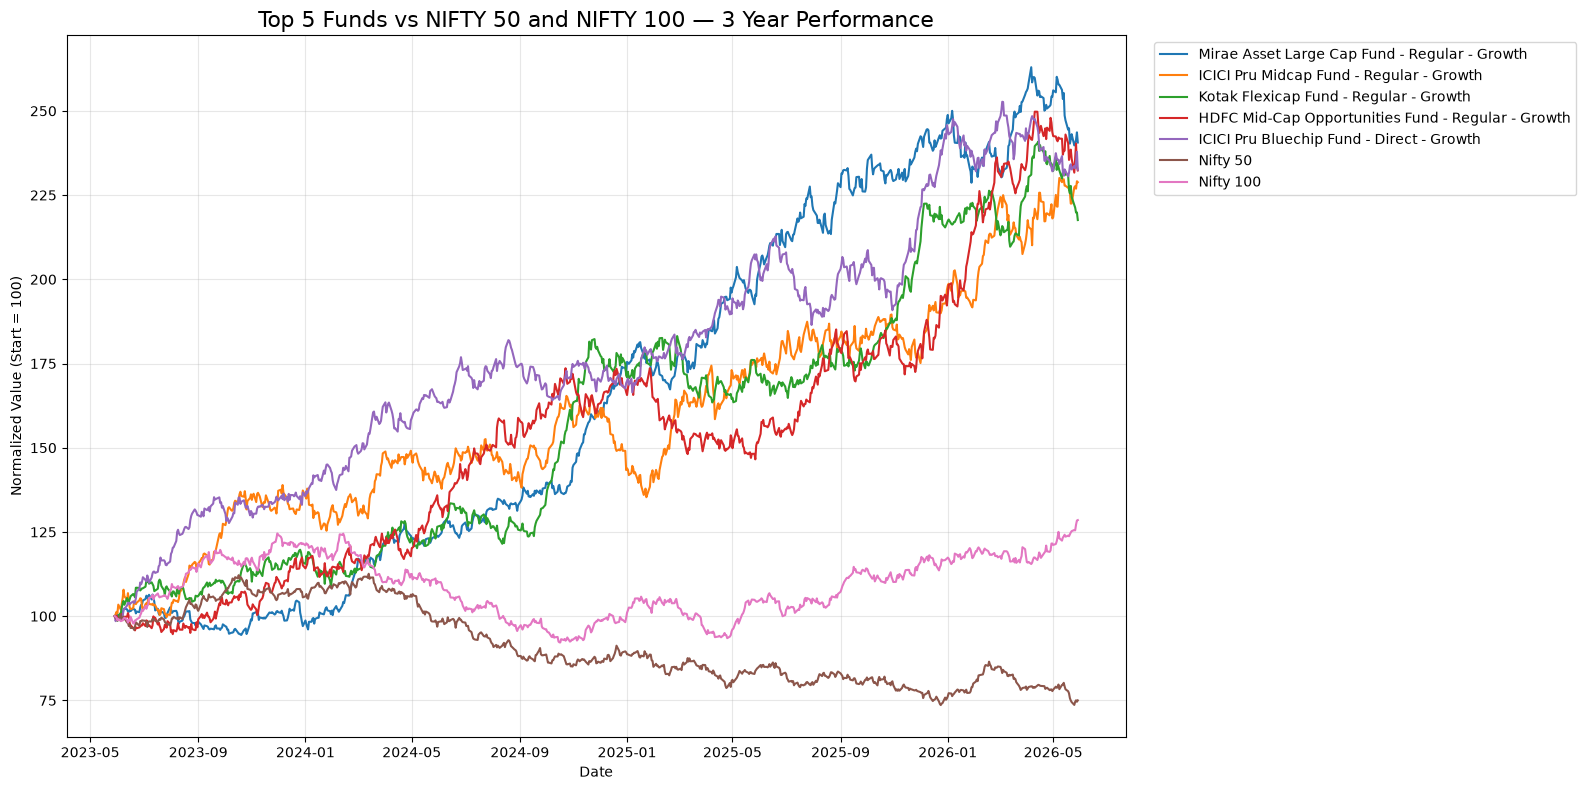

In [225]:
plt.figure(figsize=(16, 8))

for column in comparison.columns:
    plt.plot(
        comparison.index,
        comparison[column],
        label=column
    )

plt.title(
    "Top 5 Funds vs NIFTY 50 and NIFTY 100 — 3 Year Performance",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Normalized Value (Start = 100)")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../REPORTS/Charts/benchmark_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [226]:
nifty100_returns = nifty100_3y[
    ["date", "close_value"]
].copy()

nifty100_returns = nifty100_returns.sort_values("date")

nifty100_returns["benchmark_return"] = (
    nifty100_returns["close_value"].pct_change()
)

In [227]:
nifty100_returns = nifty100_returns.dropna(
    subset=["benchmark_return"]
)

In [228]:
tracking_error_results = []

for fund_name in top5_funds:

    fund = scheme[
        (scheme["scheme_name"] == fund_name) &
        (scheme["date"] >= start_date) &
        (scheme["date"] <= end_date)
    ].copy()

    fund = fund.sort_values("date")

    fund["fund_return"] = fund["nav"].pct_change()

    fund = fund[
        ["date", "fund_return"]
    ].dropna()

    merged = pd.merge(
        fund,
        nifty100_returns[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged["active_return"] = (
        merged["fund_return"] -
        merged["benchmark_return"]
    )

    tracking_error = (
        merged["active_return"].std()
        * np.sqrt(252)
    )

    tracking_error_results.append({
        "scheme_name": fund_name,
        "tracking_error": tracking_error
    })

In [229]:
tracking_error_table = pd.DataFrame(
    tracking_error_results
)

In [230]:
tracking_error_table

,scheme_name,tracking_error
0,Mirae Asset Large Cap Fund - Regular - Growth,0.187974
1,ICICI Pru Midcap Fund - Regular - Growth,0.232661
2,Kotak Flexicap Fund - Regular - Growth,0.206540
3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.224976
4,ICICI Pru Bluechip Fund - Direct - Growth,0.187299


Index(['final_rank', 'scheme_name', 'CAGR_3Y', 'sharpe_ratio', 'alpha',
       'expense_ratio_pct', 'max_drawdown', 'fund_score'],
      dtype='object')

,final_rank,scheme_name,CAGR_3Y,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown,fund_score
0,1,Mirae Asset Large Cap Fund - Regular - Growth,34.000916,1.448291,0.269838,1.46,-0.112657,86.250
1,2,ICICI Pru Midcap Fund - Regular - Growth,31.777537,1.180101,0.292636,1.36,-0.181885,82.250
2,3,Kotak Flexicap Fund - Regular - Growth,29.582770,1.306744,0.273305,1.45,-0.129740,82.000
3,4,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,32.442459,1.093699,0.271954,1.38,-0.162172,81.125
4,5,ICICI Pru Bluechip Fund - Direct - Growth,32.487429,1.026524,0.211948,0.80,-0.125883,80.000
